In [ ]:
#Import necessary libraries
import numpy as np 
import pandas as pd 


In [ ]:
#Read the dataset
df = pd.read_csv("data/retail_sales_dataset.txt")
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [ ]:
#Check the shape of the dataset
df.shape

(1000, 9)

In [ ]:
#Check the column names of the dataset
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [ ]:
#Check the data types of each column in the dataset
df.dtypes

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [ ]:
#Check the summary of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [7]:
# convert dtype for date
df["Date"] = pd.to_datetime(df["Date"])

df.dtypes

Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

In [ ]:
#Check the summary statistics of the dataset
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [ ]:
#Check the total amount of sales in the dataset
df["Total Amount"]

0       150
1      1000
2        30
3       500
4       100
       ... 
995      50
996      90
997     100
998     150
999     120
Name: Total Amount, Length: 1000, dtype: int64

In [ ]:
#Calculate the total, minimum, maximum, and average sales amount
print("Total Sales:", df["Total Amount"].sum())
print("Minimum:", df["Total Amount"].min())
print("Maximum:", df["Total Amount"].max())
print("Average:", df["Total Amount"].mean())



Total Sales: 456000
Minimum: 25
Maximum: 2000
Average: 456.0


In [ ]:
#Check for missing values in the dataset
df.isnull().sum().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [ ]:
#Sales greater than 500
high_sales = df[df["Total Amount"]> 500]

high_sales.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
12,13,2023-08-05,CUST013,Male,22,Electronics,3,500,1500
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
15,16,2023-02-17,CUST016,Male,19,Clothing,3,500,1500
19,20,2023-11-05,CUST020,Male,22,Clothing,3,300,900
25,26,2023-10-07,CUST026,Female,28,Electronics,2,500,1000
29,30,2023-10-29,CUST030,Female,39,Beauty,3,300,900
30,31,2023-05-23,CUST031,Male,44,Electronics,4,300,1200
34,35,2023-08-05,CUST035,Female,58,Beauty,3,300,900


In [ ]:
#Check for sales with quantity greater than 3
df[df["Quantity"] > 3].head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200
13,14,2023-01-17,CUST014,Male,64,Clothing,4,30,120
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
16,17,2023-04-22,CUST017,Female,27,Clothing,4,25,100
22,23,2023-04-12,CUST023,Female,35,Clothing,4,30,120
30,31,2023-05-23,CUST031,Male,44,Electronics,4,300,1200
37,38,2023-03-21,CUST038,Male,38,Beauty,4,50,200
38,39,2023-04-21,CUST039,Male,23,Clothing,4,30,120
45,46,2023-06-26,CUST046,Female,20,Electronics,4,300,1200


In [ ]:
#Check for sales with quantity less than or equal to 3
df[df["Quantity"] <= 3].head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
10,11,2023-02-14,CUST011,Male,23,Clothing,2,50,100
11,12,2023-10-30,CUST012,Male,35,Beauty,3,25,75


In [ ]:
#Check for sales in the "Electronics" product category
df[df["Product Category"] == "Electronics"].head(10)



,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
12,13,2023-08-05,CUST013,Male,22,Electronics,3,500,1500
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
17,18,2023-04-30,CUST018,Female,47,Electronics,2,25,50
25,26,2023-10-07,CUST026,Female,28,Electronics,2,500,1000
28,29,2023-08-18,CUST029,Female,42,Electronics,1,30,30
30,31,2023-05-23,CUST031,Male,44,Electronics,4,300,1200
32,33,2023-03-23,CUST033,Female,50,Electronics,2,50,100


In [ ]:
# Check for sales in the "Electronics" product category with total amount greater than 500
df[
    (df["Product Category"] == "Electronics") &
    (df["Total Amount"] > 500)
].head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
12,13,2023-08-05,CUST013,Male,22,Electronics,3,500,1500
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
25,26,2023-10-07,CUST026,Female,28,Electronics,2,500,1000
30,31,2023-05-23,CUST031,Male,44,Electronics,4,300,1200
45,46,2023-06-26,CUST046,Female,20,Electronics,4,300,1200
47,48,2023-05-16,CUST048,Male,54,Electronics,3,300,900
48,49,2023-01-23,CUST049,Female,54,Electronics,2,500,1000
53,54,2023-02-10,CUST054,Female,38,Electronics,3,500,1500
64,65,2023-12-05,CUST065,Male,51,Electronics,4,500,2000


In [ ]:
#Check for unique product categories in the dataset
df["Product Category"].unique()

<StringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str

In [ ]:
#Check for the number of unique product categories sold in the dataset
df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [ ]:
#Check for the total sales amount by product category
df.groupby("Product Category")["Total Amount"].sum()

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

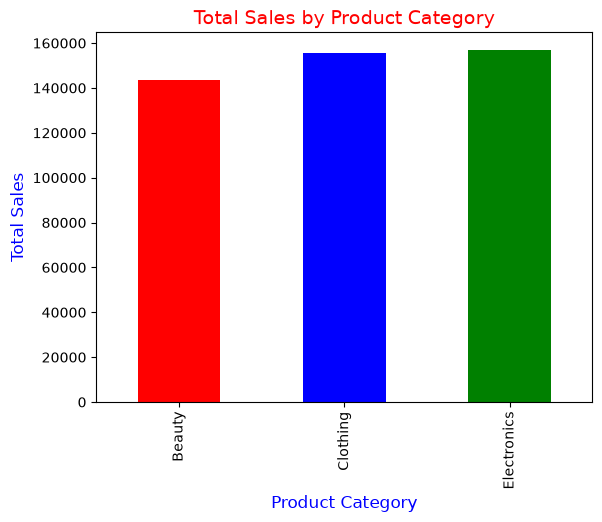

<Figure size 1000x500 with 0 Axes>

In [ ]:
#Import matplotlib for visualization
#plot the total sales by product category
import matplotlib.pyplot as plt

df.groupby("Product Category")["Total Amount"].sum().plot(
    kind="bar",color=["red", "blue", "green", "orange", "purple"]
)

plt.title("Total Sales by Product Category", color="Red", fontsize=14)
plt.xlabel("Product Category", color="Blue", fontsize=12)
plt.ylabel("Total Sales", color="Blue", fontsize=12)

#change the size of the figure
plt.figure(figsize=(10,5))



plt.show()